# 小样本 MaxEnt 训练与全量栅格投影

Acropora实际出现点/背景点的小样本训练，随后对GFDL-ESM4基线及SSP126/245/585完整原生约0.083°网格逐格投影。**不是抽样点插值，不下采样计算网格**。每个情景4338×1928个像元，逐格检查环境完整性；缺失值保留NoData。

论文《manuscript_第八版20260806》方法式(1)：
$$HSI_{qit}=HSI^{MaxEnt}_{qit}\,\Phi_{qit}^{0.5}.$$
生理函数在投影之后施加，与主线投影代码一致。Acropora的Φ为不对称高斯TPC乘文石饱和度logistic响应，参数来自当前主线配置/补充图代码，未在demo中重新拟合。

需Java 17+和requirements环境。先按README取得独立完整栅格数据包，将其解压到模块的`data/full_grid/`；在仓库根目录Run All Cells。原项目数据只读；输出在`outputs/physiology_maxent_demo/full_grid/`。计算范围仍是一个类群、一个成员、四个情景，不是四类群/三成员全集。

## 1. 环境、来源与完整栅格

先核对小样本输入及26个原始完整GeoTIFF哈希。静态底形栅格比成员环境多6行；它们与成员具有完全相同的CRS、原点及像元尺寸，因此按成员范围裁取，不插值。每个情景的有效环境掩膜均从实际输入计算。

In [1]:
from pathlib import Path
import json
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
from IPython.display import display
from analysis.modules.physiology_maxent_demo import core

ROOT = Path.cwd()
MODULE = ROOT / "analysis/modules/physiology_maxent_demo"
OUTPUT = ROOT / "outputs/physiology_maxent_demo"
OUTPUT.mkdir(parents=True, exist_ok=True)
manifest = json.loads((MODULE / "provenance.json").read_text(encoding="utf-8"))
core.verify_sources(ROOT, manifest)
JAR = MODULE / "vendor/maxent.jar"
started = time.perf_counter()
print("Native engine: MaxEnt 3.4.4; taxon: Acropora; FC=LQHP; RM=0.5")
print(f"Verified {len(manifest['packaged_files'])} packaged input files")
import rasterio
from analysis.modules.physiology_maxent_demo import full_grid
GRID_INPUTS = MODULE / "data/full_grid"
if not (GRID_INPUTS / "manifest.json").is_file():
    raise RuntimeError("Acquire the full-grid input archive described in README before running.")
grid_manifest = json.loads((GRID_INPUTS / "manifest.json").read_text(encoding="utf-8"))
for record in grid_manifest["files"]:
    if full_grid.digest(GRID_INPUTS / record["file"]) != record["sha256"]:
        raise ValueError(f"Full-grid source hash mismatch: {record['file']}")
with rasterio.open(GRID_INPUTS / "baseline/thetao.tif") as source:
    print("Full projection grid:", source.width, "x", source.height, source.crs)

Native engine: MaxEnt 3.4.4; taxon: Acropora; FC=LQHP; RM=0.5
Verified 11 packaged input files


Full projection grid: 4338 x 1928 EPSG:4326


## 2. 小样本训练数据与空间留出

固定种子的1,500个真实出现记录和10,000个真实TGB背景记录；使用原最终七变量，按5°空间块留出，不随机混合同一块。全量投影不受这个训练样本数量限制。背景不是已知缺失点。

In [2]:
presence = pd.read_csv(MODULE / "data/presence.csv.gz", float_precision="round_trip")
background = pd.read_csv(MODULE / "data/background.csv.gz", float_precision="round_trip")
for frame in (presence, background):
    if not np.isfinite(frame[core.VARIABLES].to_numpy()).all():
        raise ValueError("Non-finite training environment")
    if not frame.longitude.between(-180, 180).all() or not frame.latitude.between(-90, 90).all():
        raise ValueError("Invalid geographic coordinates")
presence_test = core.split_spatial(presence)
background_test = core.split_spatial(background)
display(presence.head())
display(pd.DataFrame({"role": ["presence", "background"],
                      "training": [(~presence_test).sum(), (~background_test).sum()],
                      "spatial_holdout": [presence_test.sum(), background_test.sum()]}))

,parent_row,longitude,latitude,bathymetry,rugosity,bottomT,thetao,si,so,zos
0,6,-128.296000,-24.328000,-1952.436938,616.235306,4.703116,26.376141,1.130916,36.408581,0.622883
1,8,-130.111000,-25.078000,-1445.235210,618.877174,6.538621,25.953520,1.137749,36.086613,0.606098
2,19,-138.833333,-9.733333,-825.893878,569.335048,24.030121,27.572954,1.579370,35.563217,0.587176
3,28,-140.666667,-7.900000,-432.781855,650.977031,12.342509,27.512894,1.821683,35.389263,0.585345
4,60,-149.666667,-17.583333,-1019.850468,701.192932,3.151799,27.016296,1.019696,36.005737,0.679037


,role,training,spatial_holdout
0,presence,1306,194
1,background,7911,2089


## 3. 原生Java MaxEnt重新训练

使用归档FC=LQHP、RM=0.5；不复用冻结lambdas，不重做全参数优化或正式10次bootstrap。原生MaxEnt可能去除重复记录，因此训练表记录数与引擎最终样本数分别报告，不能混为一谈。

In [3]:
core.swd(presence.loc[~presence_test], "Acropora", OUTPUT / "training_presence.csv")
core.swd(background.loc[~background_test], "background", OUTPUT / "training_background.csv")
MODEL_DIR = OUTPUT / "model"
MODEL_DIR.mkdir(exist_ok=True)
arguments = ["density.MaxEnt", "-z",
             f"samplesfile={OUTPUT / 'training_presence.csv'}",
             f"environmentallayers={OUTPUT / 'training_background.csv'}",
             f"outputdirectory={MODEL_DIR}",
             "betamultiplier=0.5", "autofeature=false", "linear=true", "quadratic=true",
             "product=true", "hinge=true", "threshold=false", "randomseed=false",
             "maximumbackground=-1", "threads=2", "extrapolate=false", "doclamp=true",
             "fadebyclamping=false", "outputformat=logistic", "askoverwrite=false",
             "responsecurves=false", "jackknife=false", "pictures=false"]
training_started = int(time.time())
training_log = core.run_java(JAR, arguments, OUTPUT / "training.log")
MODEL = MODEL_DIR / "Acropora.lambdas"
if not MODEL.is_file():
    raise RuntimeError("Native MaxEnt produced no fitted model")
if MODEL.stat().st_mtime < training_started:
    raise RuntimeError("Fitted model timestamp is stale")
display(pd.read_csv(MODEL_DIR / "maxentResults.csv"))
print("Newly fitted model:", MODEL.name)

,Species,#Training samples,Regularized training gain,Unregularized training gain,Iterations,Training AUC,#Background points,bathymetry contribution,bottomT contribution,rugosity contribution,...,Maximum training sensitivity plus specificity area,Maximum training sensitivity plus specificity training omission,"Balance training omission, predicted area and threshold value cumulative threshold","Balance training omission, predicted area and threshold value Logistic threshold","Balance training omission, predicted area and threshold value area","Balance training omission, predicted area and threshold value training omission",Equate entropy of thresholded and original distributions cumulative threshold,Equate entropy of thresholded and original distributions Logistic threshold,Equate entropy of thresholded and original distributions area,Equate entropy of thresholded and original distributions training omission
0,Acropora,1158,1.1917,1.2386,500,0.8855,9069,3.0973,21.5566,4.9248,...,0.2547,0.0354,2.1228,0.0864,0.3434,0.0095,3.7868,0.1468,0.3047,0.0164


Newly fitted model: Acropora.lambdas


## 4. 空间留出验证

用新模型对留出出现点/背景点调用原生`density.Project`。AUC只度量出现—背景区分度，不等同真实缺失分类准确率，也不是生理约束改善预测能力的证据。

In [4]:
def scores(frame, label):
    valid, native = core.project(JAR, MODEL, frame, OUTPUT, label)
    result = pd.Series(np.nan, index=frame.index)
    prediction_columns = [column for column in native.columns
                          if column not in ["species", "longitude", "latitude"]]
    if len(prediction_columns) != 1:
        raise ValueError(f"Unexpected native prediction columns: {list(native.columns)}")
    values = native[prediction_columns[0]].to_numpy()
    if len(values) != valid.sum() or not np.isfinite(values).all():
        raise ValueError("Incomplete native projection")
    np.testing.assert_allclose(native[["longitude", "latitude"]].to_numpy(),
                               frame.loc[valid, ["longitude", "latitude"]].to_numpy(),
                               rtol=0, atol=1e-5)
    result.loc[valid] = values
    return result

positive_scores = scores(presence.loc[presence_test], "holdout_presence")
negative_scores = scores(background.loc[background_test], "holdout_background")
holdout_auc = core.auc(positive_scores, negative_scores)
print(f"Spatial holdout presence-background AUC: {holdout_auc:.6f}")

holdout_presence: native output columns ['longitude', 'latitude', 'Acropora logistic values']


holdout_background: native output columns ['longitude', 'latitude', 'Acropora logistic values']
Spatial holdout presence-background AUC: 0.952246


## 5. 全量逐像元投影与论文一致的生理约束

对每个情景全部完整环境像元调用原生MaxEnt，无抽样或点间插值。投影flags与主线一致：`doclamp=true, extrapolate=false, fadebyclamping=true`。

$$\Phi(T,\Omega)=\exp[-(T-27)^2/(2\sigma(T)^2)]\,[1+\exp(-4(\Omega-3))]^{-1},$$
$$\sigma(T)=5\;(T\le27),\quad\sigma(T)=2\;(T>27),\qquad HSI_c=HSI_u\Phi^{0.5}.$$

T单位为°C，Ωarag无量纲；不将急性MHW再次乘入Φ。参数是原项目的结构化假设，不是本demo拟合的实验参数。保存无约束HSI、有约束HSI、生理乘子及超训练范围变量数GeoTIFF，逐像元回读验证。范围计数不是完整MESS。

摘要均值在同一个完整生理环境域上使用球面网格面积加权，避免把像元简单均值解释为全球面积均值。原始海洋网格范围内全部有效环境域参与；不额外裁成礁区。

In [5]:
training_environment = pd.concat([presence.loc[~presence_test, core.VARIABLES],
                                  background.loc[~background_test, core.VARIABLES]])
grid_results = []
for scenario in full_grid.SCENARIOS:
    result = full_grid.project_full_grid(JAR, MODEL, GRID_INPUTS, OUTPUT / "full_grid",
                                        scenario, training_environment)
    grid_results.append(result)
    display(pd.DataFrame([result]))
grid_summary = pd.DataFrame(grid_results)
grid_summary.to_csv(OUTPUT / "full_grid_summary.csv", index=False, float_format="%.17g")
display(grid_summary)

baseline: submitting all 5,603,912 complete grid cells to native MaxEnt


baseline: verified full-grid outputs


,scenario,width,height,total_grid_cells,native_projected_cells,physiology_complete_cells,missing_training_environment_cells,missing_physiology_after_maxent_cells,area_weighted_mean_unconstrained_on_common_domain,area_weighted_mean_constrained,outside_training_range_cells,elapsed_seconds,native_prediction_complete,spatial_subsampling,source_predictor_precision_preserved,maxent_projection_flags
0,baseline,4338,1928,8363664,5603912,5603912,2759752,0,0.016837,0.014195,337513,208.25,True,False,True,"[doclamp=true, extrapolate=false, fadebyclampi..."


ssp126_2050: submitting all 5,603,912 complete grid cells to native MaxEnt


ssp126_2050: verified full-grid outputs


...

,scenario,width,height,total_grid_cells,native_projected_cells,physiology_complete_cells,missing_training_environment_cells,missing_physiology_after_maxent_cells,area_weighted_mean_unconstrained_on_common_domain,area_weighted_mean_constrained,outside_training_range_cells,elapsed_seconds,native_prediction_complete,spatial_subsampling,source_predictor_precision_preserved,maxent_projection_flags
0,ssp245_2050,4338,1928,8363664,5603912,5603912,2759752,0,0.017753,0.012126,280963,211.996,True,False,True,"[doclamp=true, extrapolate=false, fadebyclampi..."


ssp585_2050: submitting all 5,603,912 complete grid cells to native MaxEnt


ssp585_2050: verified full-grid outputs


,scenario,width,height,total_grid_cells,native_projected_cells,physiology_complete_cells,missing_training_environment_cells,missing_physiology_after_maxent_cells,area_weighted_mean_unconstrained_on_common_domain,area_weighted_mean_constrained,outside_training_range_cells,elapsed_seconds,native_prediction_complete,spatial_subsampling,source_predictor_precision_preserved,maxent_projection_flags
0,ssp585_2050,4338,1928,8363664,5603912,5603912,2759752,0,0.018225,0.010908,314241,209.781,True,False,True,"[doclamp=true, extrapolate=false, fadebyclampi..."


,scenario,width,height,total_grid_cells,native_projected_cells,physiology_complete_cells,missing_training_environment_cells,missing_physiology_after_maxent_cells,area_weighted_mean_unconstrained_on_common_domain,area_weighted_mean_constrained,outside_training_range_cells,elapsed_seconds,native_prediction_complete,spatial_subsampling,source_predictor_precision_preserved,maxent_projection_flags
0,baseline,4338,1928,8363664,5603912,5603912,2759752,0,0.016837,0.014195,337513,208.250,True,False,True,"[doclamp=true, extrapolate=false, fadebyclampi..."
1,ssp126_2050,4338,1928,8363664,5603912,5603912,2759752,0,0.017720,0.013006,271195,211.410,True,False,True,"[doclamp=true, extrapolate=false, fadebyclampi..."
2,ssp245_2050,4338,1928,8363664,5603912,5603912,2759752,0,0.017753,0.012126,280963,211.996,True,False,True,"[doclamp=true, extrapolate=false, fadebyclampi..."
3,ssp585_2050,4338,1928,8363664,5603912,5603912,2759752,0,0.018225,0.010908,314241,209.781,True,False,True,"[doclamp=true, extrapolate=false, fadebyclampi..."


## 6. 连续栅格地图

下面直接读取全量GeoTIFF，而非画训练点或抽样点。无约束与有约束图使用同一0–1色标；缺失环境显示为灰色（不一定都是陆地）。显示分辨率可以低于计算分辨率，但不改变源GeoTIFF。PNG、SVG、PDF一并保存。

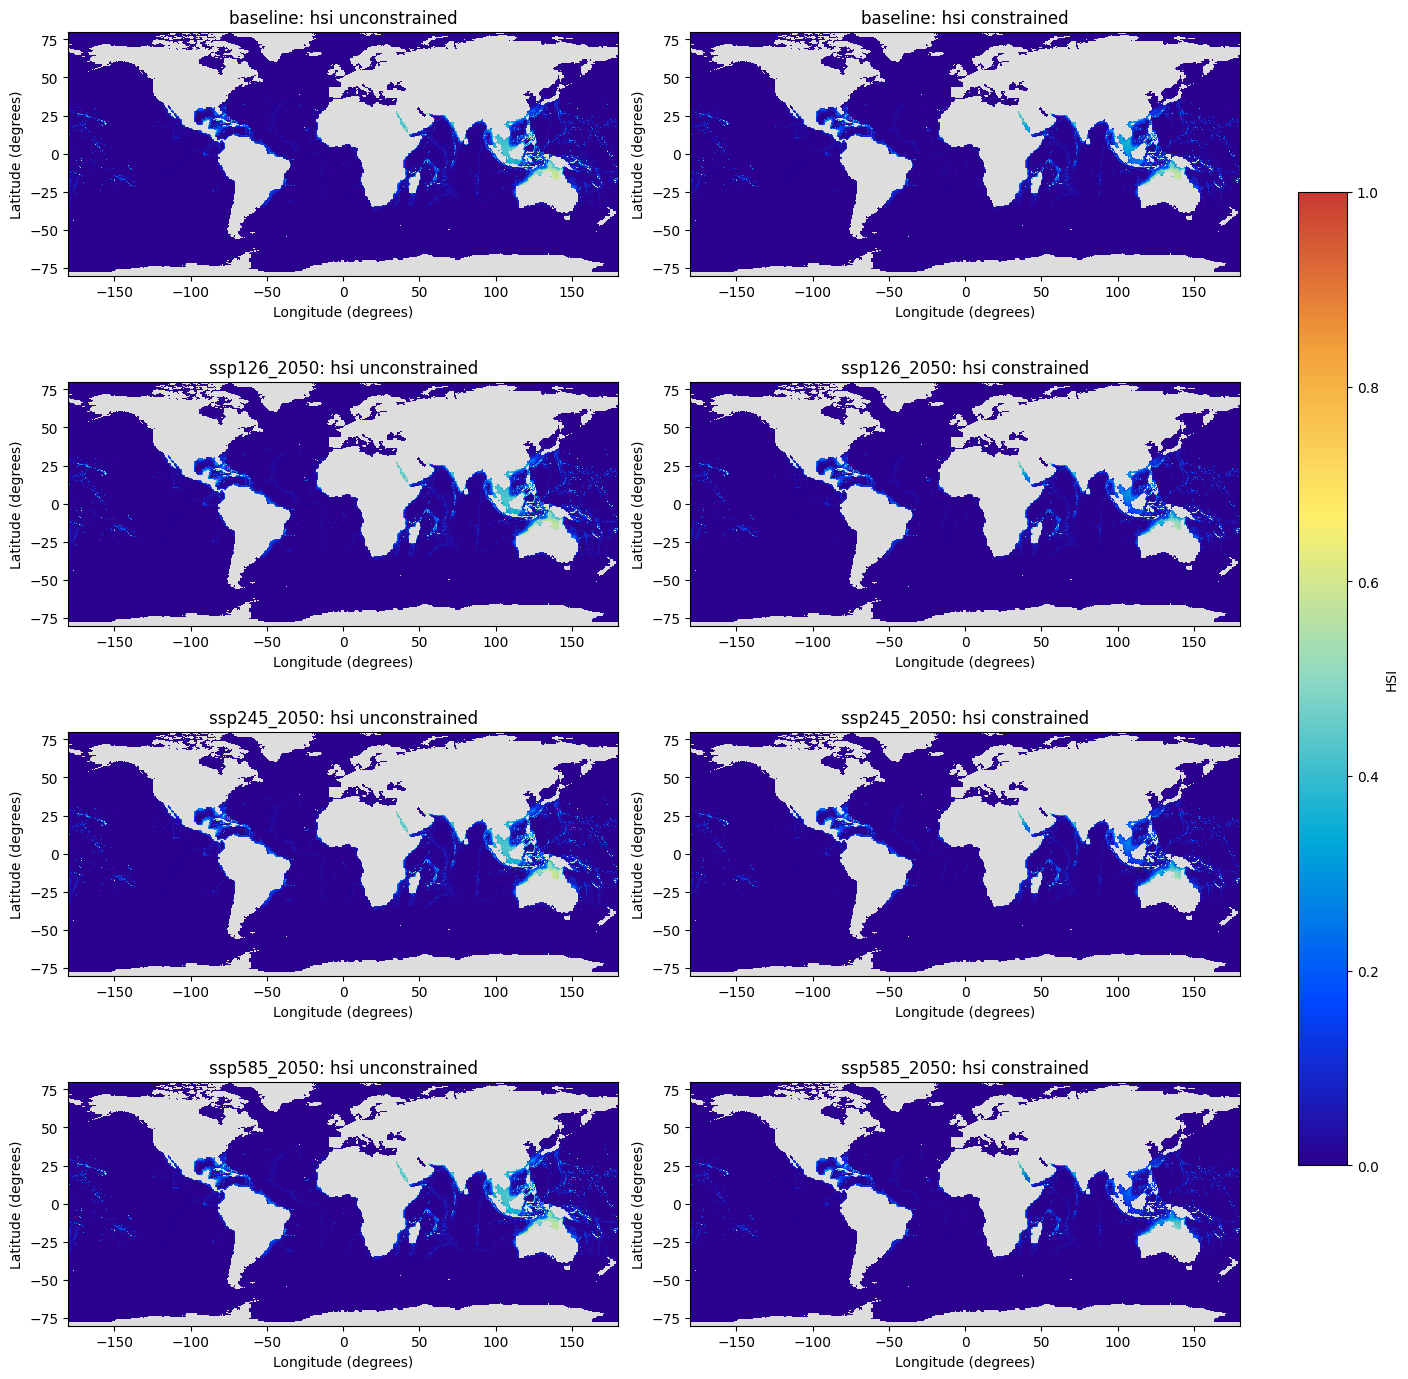

In [6]:
from matplotlib.colors import LinearSegmentedColormap
plt.rcParams.update({"svg.fonttype": "none", "pdf.fonttype": 42})
cmap = LinearSegmentedColormap.from_list("project_hsi", [
    "#2B008F", "#0047FF", "#00A9D6", "#8ED9C4", "#FFF06A", "#F3A43B", "#C93A32"])
cmap.set_bad("#dddddd")
fig, axes = plt.subplots(4, 2, figsize=(14, 14), constrained_layout=True)
for row, scenario in enumerate(full_grid.SCENARIOS):
    for column, field in enumerate(["hsi_unconstrained", "hsi_constrained"]):
        with rasterio.open(OUTPUT / "full_grid" / scenario / f"{field}.tif") as source:
            data = source.read(1, masked=True)
            bounds = source.bounds
        panel = axes[row, column].imshow(data, extent=[bounds.left, bounds.right, bounds.bottom, bounds.top],
                                          origin="upper", cmap=cmap, vmin=0, vmax=1, interpolation="nearest")
        axes[row, column].set(title=f"{scenario}: {field.replace('_', ' ')}",
                              xlabel="Longitude (degrees)", ylabel="Latitude (degrees)")
fig.colorbar(panel, ax=axes, shrink=0.7, label="HSI")
for extension in ["png", "svg", "pdf"]:
    fig.savefig(OUTPUT / f"full_grid_hsi_comparison.{extension}", dpi=160)
plt.show()

## 7. 完整执行证据

保存新模型的有效训练数、空间留出AUC、每个情景全栅格数/实际投影数/NoData数以及来源。小样本重训不会产生原正式模型的相同结果；这里只对方法公式、真实输入、全量覆盖和计算实现负责，不复制论文正式性能数字。

In [7]:
native_results = pd.read_csv(MODEL_DIR / "maxentResults.csv")
report = {"status": "passed", "entrypoint": "Physiology_MaxEnt_demo.ipynb",
          "taxon": "Acropora", "member": grid_manifest["member"],
          "native_maxent_version": "3.4.4", "full_spatial_projection": True,
          "spatial_subsampling": False, "full_parent_reproduction": False,
          "training_presence_table_rows": int((~presence_test).sum()),
          "native_training_presence_count": int(native_results["#Training samples"].iloc[0]),
          "training_background_table_rows": int((~background_test).sum()),
          "spatial_holdout_presence_background_auc": holdout_auc,
          "projection_rows": int(grid_summary.native_projected_cells.sum()),
          "full_grid_input_hashes_checked": len(grid_manifest["files"]),
          "formula": "HSI_constrained = HSI_MaxEnt * Phi ** 0.5",
          "formula_authority": "manuscript_第八版20260806 Eq. 1 and active parent projection",
          "scenarios": grid_results, "elapsed_seconds": round(time.perf_counter() - started, 3)}
for record in grid_manifest["files"]:
    if full_grid.digest(GRID_INPUTS / record["file"]) != record["sha256"]:
        raise ValueError("Full source changed during execution")
core.verify_sources(ROOT, manifest)
(OUTPUT / "run_checks.json").write_text(json.dumps(report, indent=2) + "\n", encoding="utf-8")
print("Verified full-grid projections saved to outputs/physiology_maxent_demo/full_grid/")

Verified full-grid projections saved to outputs/physiology_maxent_demo/full_grid/
